# 02. Neural Network classification with PyTorch

## 1. Make classification data

In [119]:
import sklearn
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
len(X), len(y)

(1000, 1000)

In [120]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [121]:
# Make DataFrame of circle fata
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y})
circles.head(5)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


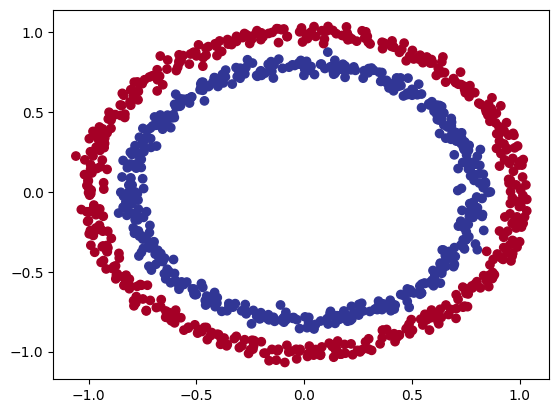

In [122]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

### 1.1 Check input and outputs shape

In [123]:
X.shape, y.shape

((1000, 2), (1000,))

In [124]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and y: {y_sample}")

Values for one sample of X: [0.75424625 0.23148074] and y: 1


### Trun data into tensors and create train and test split

In [125]:
import torch
torch.__version__

'2.11.0+cpu'

In [126]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [127]:
type(X)

torch.Tensor

In [128]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [129]:
# Split data into training and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% of data will be test
                                                    random_state=42)

In [130]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Let's build a model to classify our blue and red dots

To do so, we want to:
1. Setup device agnostic code
2. Construct a model (subclass nn.Module)
3. Define loss function and optimizer
4. Finally create a training and test loop

In [131]:
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [132]:
# Create a model
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 featurs and upscales to 5 features
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features from previous layer and outputs a single feature (y)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_2(self.layer_1(x))

In [133]:
# Create an instance and set to target device
model_0 = CircleModelV0().to(device)
next(model_0.parameters()).device

device(type='cpu')

In [134]:
# Let's replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [135]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [136]:
# Make predictions
model_0.eval()
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"First 10 predictions: \n{untrained_preds[:10]}")
len(untrained_preds), untrained_preds.shape

First 10 predictions: 
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]])


(200, torch.Size([200, 1]))

### 2.1 Setup loss function and optimizer

For regression you might want MAE or MSE

For classification you might want binary cross entropy or categorical cross entropy

And for optimizers, two of the most common and useful are SGD and Adam

In [137]:
# Loss function
# loss_fn = nn.BCE() # requires inputs to have gone through the sgmoid activation function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss() # Sigmoid activation function built in

# optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [138]:
# Calculate accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

## 3. Train model

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward
5. Optimizer step

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be **raw logits**.

We can convert these **logits** into prediction probabilities by passing them to some kind of activation function (e.g. sigmoid for BCE and softmax for multiclass classification)

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the *argmax()*

In [139]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))
y_logits[:5]

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

In [140]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [141]:
# Use the sigmoid activation function on our model logits to turn the into predictions probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs[:5]

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]])

For our prediction probability values, we need to perform a range-style rounding on them:
* if >= 0.5, y=1 (class 1)
* if < 0.5, y=0 (class 0)

In [142]:
# Find the predicted labes
y_preds = torch.round(y_pred_probs)
y_preds[:5]

# In full
y_preds_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_preds_labels.squeeze()))

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

### 3.2 Build a training and a testing loop

In [143]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Training
  model_0.train()

  # Forward pass
  y_logits = model_0(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

  # Calculate loss and accuracy
  loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                 y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_preds)

  # Optim zero grad
  optimizer.zero_grad()

  # Backward prop
  loss.backward()

  # Optimizer step
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Calculate loss and accuracy
    test_loss = loss_fn(test_logits,
                        y_test)

    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  if epoch % 20 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796 | Acc: 51.88% | Test loss: 0.69440 | Test acc: 58.00%
Epoch: 20 | Loss: 0.69490 | Acc: 51.62% | Test loss: 0.69254 | Test acc: 49.50%
Epoch: 40 | Loss: 0.69401 | Acc: 50.88% | Test loss: 0.69232 | Test acc: 51.00%
Epoch: 60 | Loss: 0.69362 | Acc: 50.00% | Test loss: 0.69239 | Test acc: 51.50%
Epoch: 80 | Loss: 0.69342 | Acc: 49.88% | Test loss: 0.69254 | Test acc: 50.00%


## 4. Inspect why the model isn't learning

Make predictions and evaluate the model.



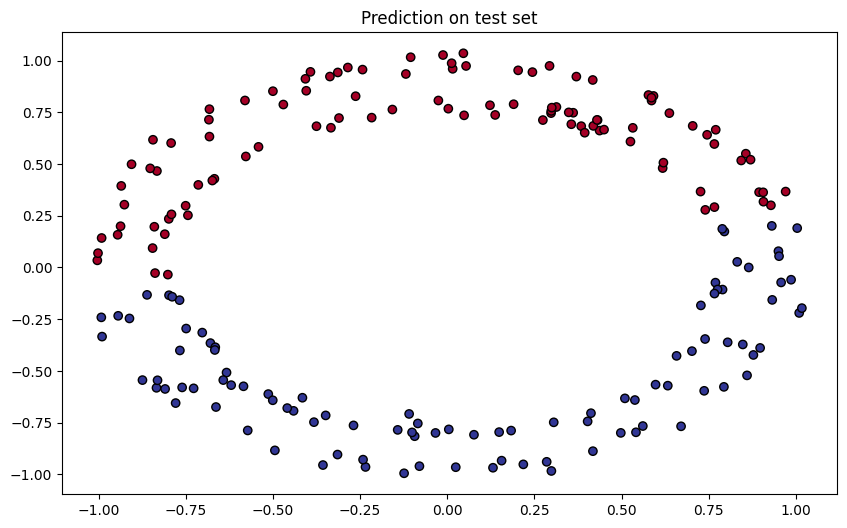

In [144]:
import matplotlib.pyplot as plt

model_0.eval()
with torch.inference_mode():
    test_logits = model_0(X_test.to(device))
    test_preds = torch.round(torch.sigmoid(test_logits)).cpu().numpy().squeeze()

X_test_np = X_test.cpu().numpy()

plt.figure(figsize=(10, 6))
plt.scatter(X_test_np[:, 0], X_test_np[:, 1], c=test_preds, cmap=plt.cm.RdYlBu, edgecolors="k")
plt.title("Prediction on test set")
plt.show()

### 5. The data is not linearly separable. We need to improve the model

* Add more layers
* Add more hidden units
* Fit for longer
* Changing/adding the activation functions
* Change the learning rate
* Change the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data.

We need to manipulate the **hyperparameters**

In [145]:
# Let's try increasing the number of hidden units 5 -> 10
# Increase layers 2 -> 3
# Increase epochs 100 -> 1000
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [146]:
# Create loss funciton
loss_fn = nn.BCEWithLogitsLoss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [147]:
# Create a training and evaluation loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Training
  model_1.train()

  # Forward pass
  y_logits = model_1(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  # Loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

  # Optimizer zero grad
  optimizer.zero_grad()

  # Backprop
  loss.backward()

  # Optimizer step
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Acc: 50.88% | Test loss: 0.69261 | Test acc: 51.00%
Epoch: 100 | Loss: 0.69369 | Acc: 50.25% | Test loss: 0.69269 | Test acc: 50.00%
Epoch: 200 | Loss: 0.69351 | Acc: 50.12% | Test loss: 0.69282 | Test acc: 49.50%
Epoch: 300 | Loss: 0.69339 | Acc: 50.50% | Test loss: 0.69295 | Test acc: 49.00%
Epoch: 400 | Loss: 0.69329 | Acc: 50.38% | Test loss: 0.69309 | Test acc: 48.50%
Epoch: 500 | Loss: 0.69322 | Acc: 49.88% | Test loss: 0.69322 | Test acc: 49.50%
Epoch: 600 | Loss: 0.69317 | Acc: 49.50% | Test loss: 0.69335 | Test acc: 53.00%
Epoch: 700 | Loss: 0.69313 | Acc: 49.38% | Test loss: 0.69347 | Test acc: 50.50%
Epoch: 800 | Loss: 0.69309 | Acc: 50.00% | Test loss: 0.69358 | Test acc: 51.00%
Epoch: 900 | Loss: 0.69307 | Acc: 50.62% | Test loss: 0.69368 | Test acc: 47.50%


Let's go back to linear data, to see if our model can solve a smaller problem

In [148]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # Linear regression formula (without epsilon)

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [149]:
# Create train and test splits
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]
len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

In [150]:
# Adjusting model, same architecture but useing nn.Sequential()
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [151]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr = 0.001)

In [152]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put data on target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Loop through epochs
for epoch in range(epochs):
  # Training
  model_2.train()
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test loss: 0.94965
Epoch: 100 | Loss: 0.40272 | Test loss: 0.54029
Epoch: 200 | Loss: 0.05876 | Test loss: 0.13480
Epoch: 300 | Loss: 0.01461 | Test loss: 0.03342
Epoch: 400 | Loss: 0.00308 | Test loss: 0.00008
Epoch: 500 | Loss: 0.00309 | Test loss: 0.00012
Epoch: 600 | Loss: 0.00309 | Test loss: 0.00018
Epoch: 700 | Loss: 0.00299 | Test loss: 0.00011
Epoch: 800 | Loss: 0.00299 | Test loss: 0.00016
Epoch: 900 | Loss: 0.00289 | Test loss: 0.00011


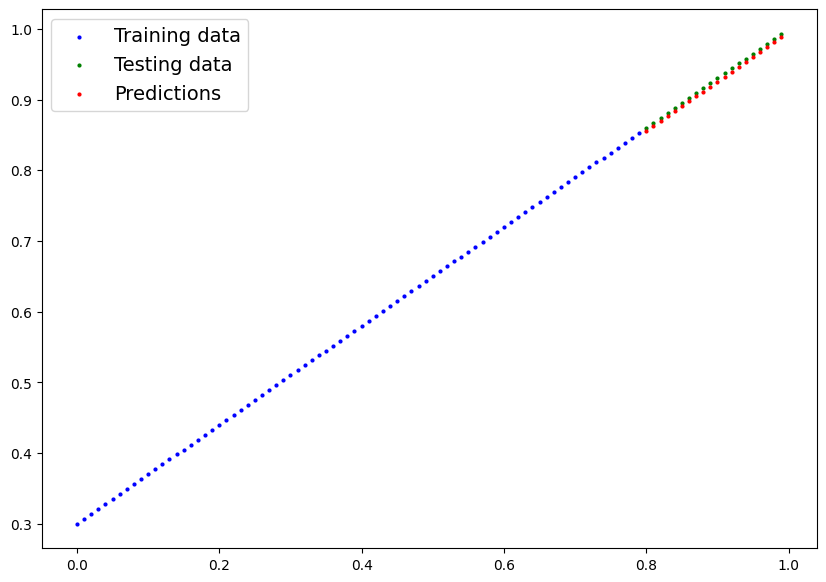

In [153]:
# Plot predictions
def plot_predictions(train_data= X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  '''
  Plots training data, test data and compares predictions.
  '''
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c='g', s=4, label="Testing data")

  # Are there predictions?
  if predictions is not None:
    # Plot the predictions
    plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})


model_2.eval()
with torch.inference_mode():
  y_pred_regression = model_2(X_test_regression)
plot_predictions(X_train_regression.cpu(),
                 y_train_regression.cpu(),
                 X_test_regression.cpu(),
                 y_test_regression.cpu(),
                 y_pred_regression.cpu())

The model is learning from linear data, we need non linear activations

## Non-linearity

"What patterns could you draw if ou were given an infinite amout of straight and non-straight lines?"

Or in ML terms, and infinite (but really it is finite) of linear and non-linear functions?

### 6. Recreating non-linear data

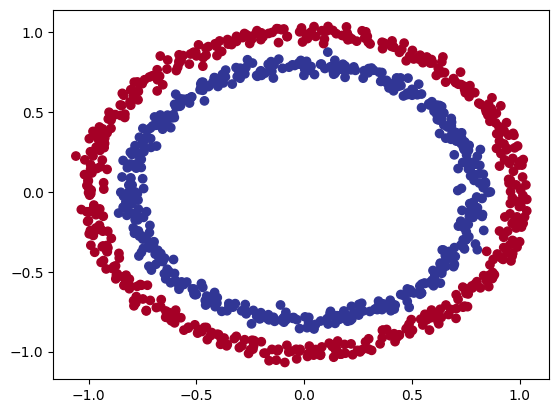

In [154]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=n_samples, noise = 0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [155]:
# Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 6.2 Building a model with non-linearity

In [156]:
# Model with non-linear activations
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU() # Non linear activation function

  def forward(self, x):
      return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [157]:
# Loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

In [158]:
# Training loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1500

# Move data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Training
  model_3.train()

  y_logits = model_3(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295 | Acc: 50.00% | Test loss: 0.69319 | Test acc: 50.00%
Epoch: 100 | Loss: 0.69115 | Acc: 52.88% | Test loss: 0.69102 | Test acc: 52.50%
Epoch: 200 | Loss: 0.68977 | Acc: 53.37% | Test loss: 0.68940 | Test acc: 55.00%
Epoch: 300 | Loss: 0.68795 | Acc: 53.00% | Test loss: 0.68723 | Test acc: 56.00%
Epoch: 400 | Loss: 0.68517 | Acc: 52.75% | Test loss: 0.68411 | Test acc: 56.50%
Epoch: 500 | Loss: 0.68102 | Acc: 52.75% | Test loss: 0.67941 | Test acc: 56.50%
Epoch: 600 | Loss: 0.67515 | Acc: 54.50% | Test loss: 0.67285 | Test acc: 56.00%
Epoch: 700 | Loss: 0.66659 | Acc: 58.38% | Test loss: 0.66322 | Test acc: 59.00%
Epoch: 800 | Loss: 0.65160 | Acc: 64.00% | Test loss: 0.64757 | Test acc: 67.50%
Epoch: 900 | Loss: 0.62362 | Acc: 74.00% | Test loss: 0.62145 | Test acc: 79.00%
Epoch: 1000 | Loss: 0.56818 | Acc: 87.75% | Test loss: 0.57378 | Test acc: 86.50%
Epoch: 1100 | Loss: 0.48153 | Acc: 93.50% | Test loss: 0.49935 | Test acc: 90.50%
Epoch: 1200 | Loss: 0.37056 

### 6.4 Evaluating a model trained with non-linear activation functions

In [159]:
# Make predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test).squeeze()))
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

## 8. Putting it all together with a multi-class classification problem

### 8.1 Creating a toy multi-class dataset

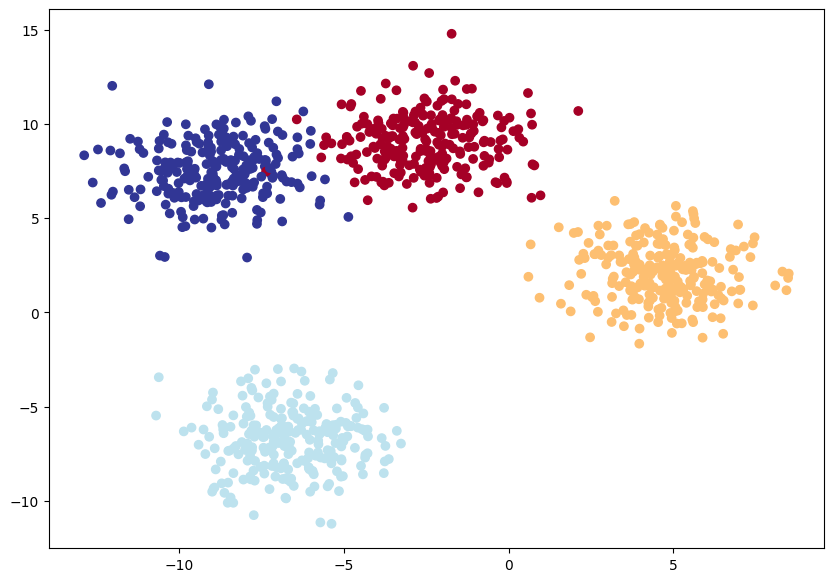

In [160]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import numpy as np

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # Give clusters a little shake up
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split data
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# 4. Plot and visualize
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

### 8.2 Building a multi-class classification model in PyTorch

In [161]:
# Create device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [162]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """ Initializes multi-class classification model.

    Args:
      input_features (int): Number of input features to the model
      output_features (int): Number of outputs features (number of output classes)
      hidden_units (int): Number of hidden units between layers, default 8

    Returns:

    Example:
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instante and send to device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 8.3 Create a loss function and optimizer for a multi-class problem

In [163]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.01)

### 8.4 Getting prediction probabilities for a multi-class model

In [164]:
# Let's get some raw outputs (logits) of the model

model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))
y_logits[:10]

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]])

In [165]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [166]:
# Convert logits into prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951],
        [0.2788, 0.0088, 0.2893, 0.4232],
        [0.3246, 0.1261, 0.4545, 0.0948],
        [0.2229, 0.0443, 0.1867, 0.5461],
        [0.3447, 0.0368, 0.5269, 0.0917],
        [0.2145, 0.0510, 0.1752, 0.5593]])

In [167]:
# Convert our model's prediction probs to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3])

### 8.5 Creating a training loop and testing loop

In [168]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Move data to target device
X_train, y_train = X_blob_train.to(device), y_blob_train.to(device)
X_test, y_test = X_blob_test.to(device), y_blob_test.to(device)

epochs = 100

for epoch in range(epochs):
  model_4.train()
  y_logits = model_4(X_train)
  y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_test)
  test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
  test_loss = loss_fn(test_logits, y_test)
  test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Acc: {acc} | Test loss: {test_loss} | Test acc: {test_acc}")

Epoch: 0 | Loss: 1.0432370901107788 | Acc: 65.5 | Test loss: 0.963351309299469 | Test acc: 71.0
Epoch: 10 | Loss: 0.6368808746337891 | Acc: 79.5 | Test loss: 0.6122152209281921 | Test acc: 88.0
Epoch: 20 | Loss: 0.4694470465183258 | Acc: 97.75 | Test loss: 0.45864737033843994 | Test acc: 98.0
Epoch: 30 | Loss: 0.37339234352111816 | Acc: 98.5 | Test loss: 0.3677147924900055 | Test acc: 99.0
Epoch: 40 | Loss: 0.31008732318878174 | Acc: 98.625 | Test loss: 0.3065946102142334 | Test acc: 99.0
Epoch: 50 | Loss: 0.26485675573349 | Acc: 98.875 | Test loss: 0.2622745633125305 | Test acc: 99.0
Epoch: 60 | Loss: 0.23081865906715393 | Acc: 98.875 | Test loss: 0.2285250425338745 | Test acc: 99.5
Epoch: 70 | Loss: 0.20428618788719177 | Acc: 99.125 | Test loss: 0.20196585357189178 | Test acc: 99.5
Epoch: 80 | Loss: 0.18307241797447205 | Acc: 99.125 | Test loss: 0.18056653439998627 | Test acc: 99.0
Epoch: 90 | Loss: 0.16577735543251038 | Acc: 99.125 | Test loss: 0.1630103439092636 | Test acc: 99.0


In [169]:
# Make predictions
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_test)
y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
y_pred[:10], y_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]))

In [170]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

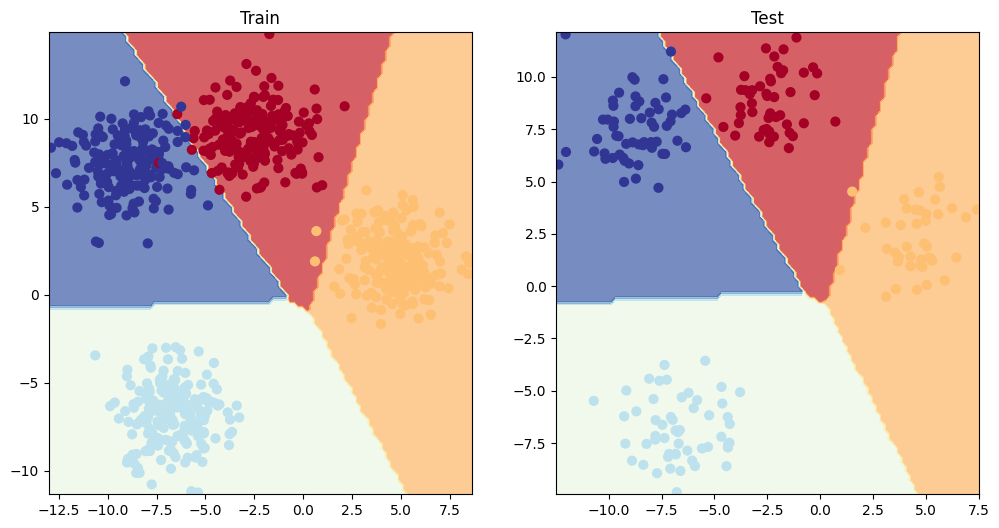

In [171]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more classification metrics

* Accuracy: percentage of times our model is right
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report

In [172]:
!pip install torchmetrics

In [173]:
from torchmetrics import Accuracy

# Setup metric
acc = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)

# Calculate accuracy
acc(y_pred.to(device), y_blob_test.to(device))

tensor(0.9900)

## Exercises

In [174]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

RANDOM_SEED = 42

In [175]:
from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000,
                  noise=0.03,
                  random_state=RANDOM_SEED)
print(len(X), len(y))
X[:5], y[:5]

1000 1000


(array([[-0.00933187,  0.39098105],
        [ 0.95457387, -0.47375583],
        [ 0.9185256 , -0.42519648],
        [ 0.41276802, -0.37638459],
        [-0.84532016,  0.52879908]]),
 array([1, 1, 1, 1, 0]))

In [176]:
moons = pd.DataFrame({'X1': X[:, 0],
                  'X2': X[:, 1],
                  'y': y})
moons.head(5)

,X1,X2,y
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0


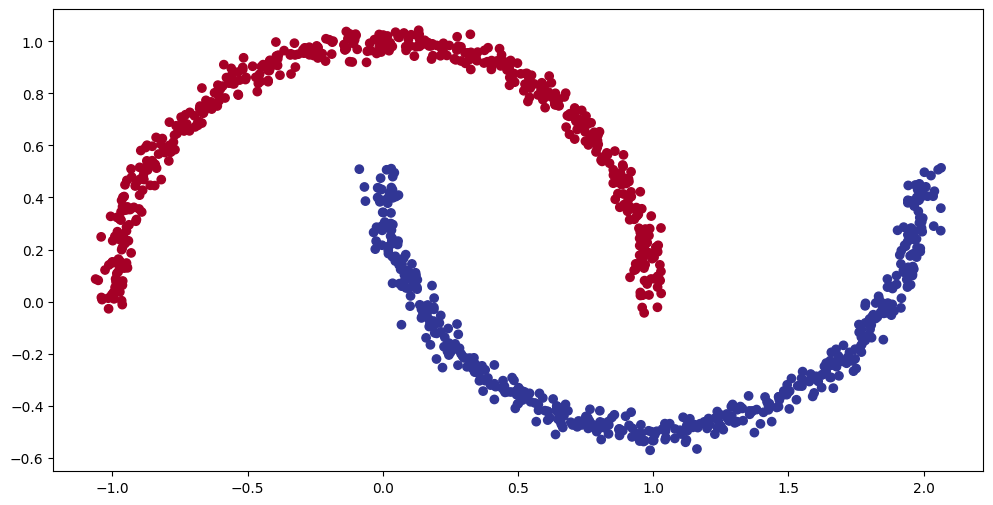

In [177]:
plt.figure(figsize=(12, 6))
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

In [178]:
X = torch.from_numpy(X).type(torch.float).to(device)
y = torch.from_numpy(y).type(torch.float).to(device)
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=RANDOM_SEED)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [180]:
class MoonModelV0(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=1)
    )

  def forward(self, x):
    return self.layers(x)

model_5 = MoonModelV0(input_features=2, output_features=1, hidden_units=512)
model_5.to(device)

MoonModelV0(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [181]:
# Setup loss fn and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_5.parameters(), lr=0.1)

In [182]:
# Training and testing loop
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

# Move data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 300

for epoch in range(epochs):
  model_5.train()
  y_logits = model_5(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_preds)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_5.eval()
  with torch.inference_mode():
    test_logits = model_5(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Train loss: {loss} | Train acc: {acc} | Test loss: {test_loss} | Test acc: {test_acc}")


Epoch: 0 | Train loss: 0.7020795345306396 | Train acc: 50.0 | Test loss: 0.6177871823310852 | Test acc: 74.0
Epoch: 10 | Train loss: 0.3318540155887604 | Train acc: 84.625 | Test loss: 0.33855000138282776 | Test acc: 84.5
Epoch: 20 | Train loss: 0.2630869150161743 | Train acc: 87.375 | Test loss: 0.26786985993385315 | Test acc: 88.5
Epoch: 30 | Train loss: 0.23042230308055878 | Train acc: 89.125 | Test loss: 0.23140132427215576 | Test acc: 90.5
Epoch: 40 | Train loss: 0.20912444591522217 | Train acc: 89.875 | Test loss: 0.20761455595493317 | Test acc: 91.0
Epoch: 50 | Train loss: 0.19275885820388794 | Train acc: 90.875 | Test loss: 0.1897508203983307 | Test acc: 92.5
Epoch: 60 | Train loss: 0.17856918275356293 | Train acc: 91.625 | Test loss: 0.17470988631248474 | Test acc: 93.0
Epoch: 70 | Train loss: 0.16544124484062195 | Train acc: 92.875 | Test loss: 0.1610765904188156 | Test acc: 93.0
Epoch: 80 | Train loss: 0.15293003618717194 | Train acc: 93.75 | Test loss: 0.14827197790145874 |

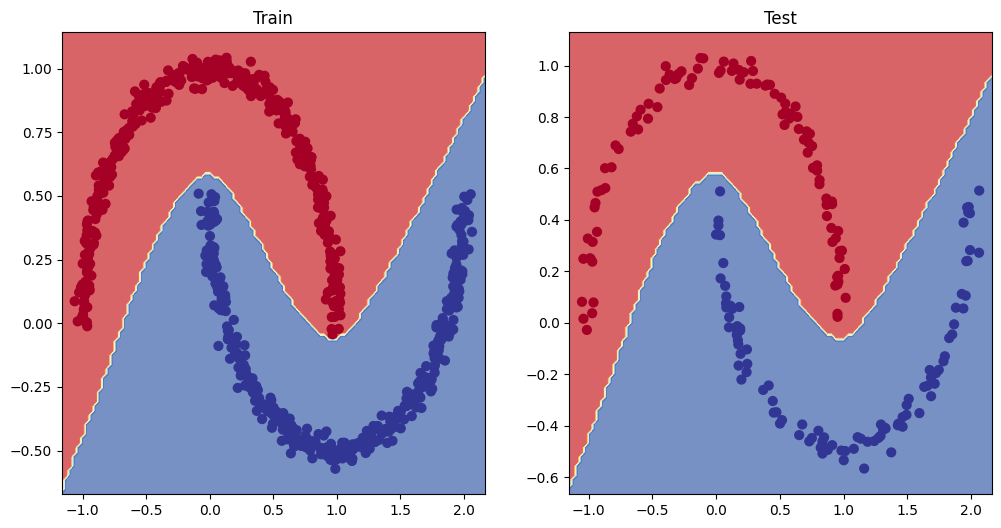

In [183]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_5, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_5, X_test, y_test)

### Replicate the Tanh activation function

In [184]:
# Create a straight line tensor
weight = 2
bias = 1

start = -2
end = 2
step = 0.1

X = torch.arange(start, end, step).to(device)
y = weight * X + bias
X.shape, y.shape

(torch.Size([40]), torch.Size([40]))

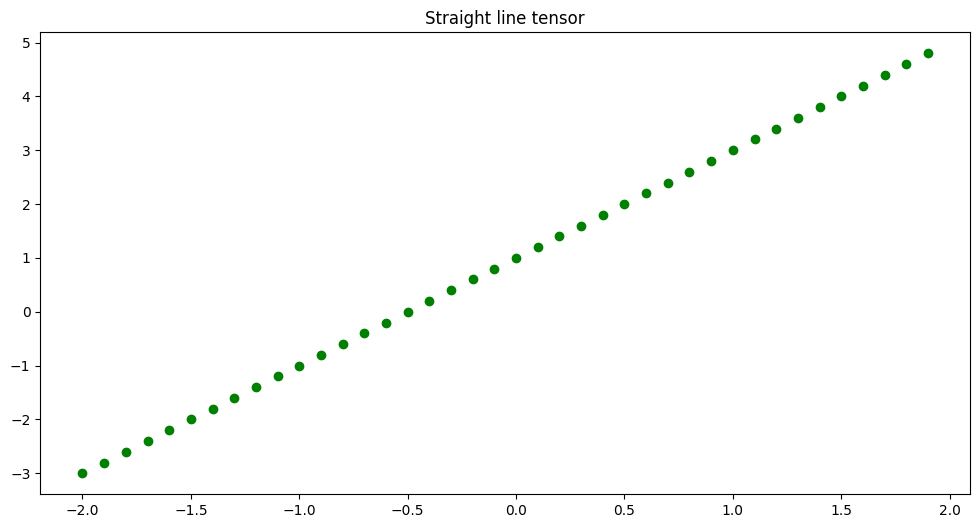

In [185]:
# Plot current tensor
plt.figure(figsize=(12, 6))
plt.title("Straight line tensor")
plt.scatter(X.to('cpu'), y.to('cpu'), c='g')

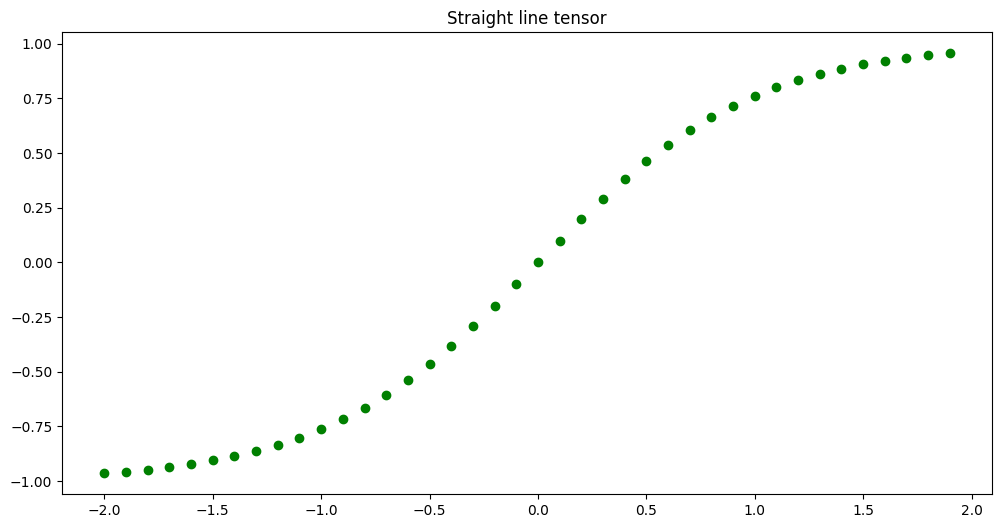

In [186]:
y = torch.tanh(X)
plt.figure(figsize=(12, 6))
plt.title("Straight line tensor")
plt.scatter(X.to('cpu'), y.to('cpu'), c='g')

In [187]:
# Replicate tanh
def tanh(X: torch.Tensor) -> torch.Tensor:
  return (torch.exp(X) - torch.exp(-X)) / (torch.exp(X) + torch.exp(-X))

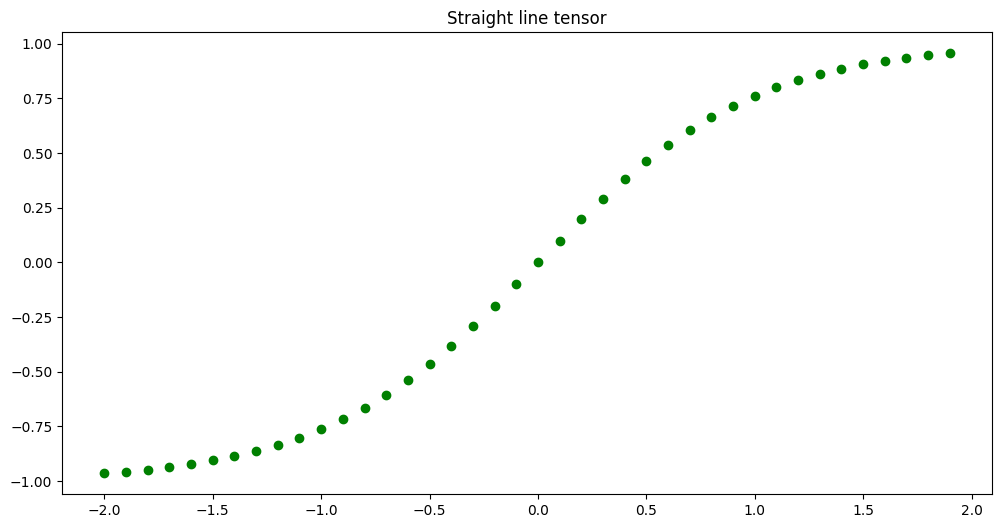

In [188]:
y = tanh(X)
plt.figure(figsize=(12, 6))
plt.title("Straight line tensor")
plt.scatter(X.to('cpu'), y.to('cpu'), c='g')

### Create a multi-class dataset using the spirals data creation function from CS231

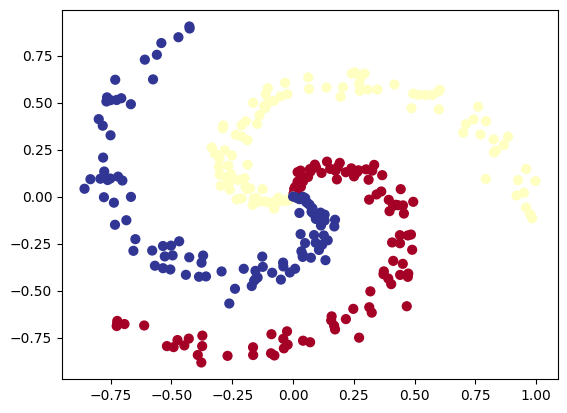

In [189]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [190]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([225, 2]),
 torch.Size([75, 2]),
 torch.Size([225]),
 torch.Size([75]))

In [191]:
!pip -q install torchmetrics

In [192]:
from torchmetrics import Accuracy
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device)
acc_fn

MulticlassAccuracy()

In [193]:
class SpiralModelV0(nn.Module):
  def __init__(self, in_features, out_features, hidden_units=8):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(in_features=in_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=out_features)
    )

  def forward(self, x):
    return self.layers(x)

model_6 = SpiralModelV0(in_features=2, out_features=3, hidden_units=512).to(device)
model_6

SpiralModelV0(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=3, bias=True)
  )
)

In [194]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_6.parameters(), lr=0.1)

In [195]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Move data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 300

for epoch in range(epochs):
  model_6.train()
  y_logits = model_6(X_train)
  y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_train, y_preds)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_6.eval()
  with torch.inference_mode():
    test_logits = model_6(X_test)
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(y_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Train loss: {loss} | Train acc: {acc} | Test loss: {test_loss} | Test acc: {test_acc}")


Epoch: 0 | Train loss: 1.110935091972351 | Train acc: 0.36000001430511475 | Test loss: 1.0643545389175415 | Test acc: 0.5866666436195374
Epoch: 10 | Train loss: 0.8373948335647583 | Train acc: 0.5688889026641846 | Test loss: 0.8691879510879517 | Test acc: 0.47999998927116394
Epoch: 20 | Train loss: 0.7347254753112793 | Train acc: 0.5688889026641846 | Test loss: 0.7901978492736816 | Test acc: 0.4933333396911621
Epoch: 30 | Train loss: 0.6907148957252502 | Train acc: 0.5733333230018616 | Test loss: 0.7532601356506348 | Test acc: 0.5066666603088379
Epoch: 40 | Train loss: 0.6631552577018738 | Train acc: 0.5733333230018616 | Test loss: 0.727788507938385 | Test acc: 0.5199999809265137
Epoch: 50 | Train loss: 0.6395229697227478 | Train acc: 0.5866666436195374 | Test loss: 0.7051767706871033 | Test acc: 0.5199999809265137
Epoch: 60 | Train loss: 0.6163896918296814 | Train acc: 0.6000000238418579 | Test loss: 0.6825088262557983 | Test acc: 0.5333333611488342
Epoch: 70 | Train loss: 0.592610120

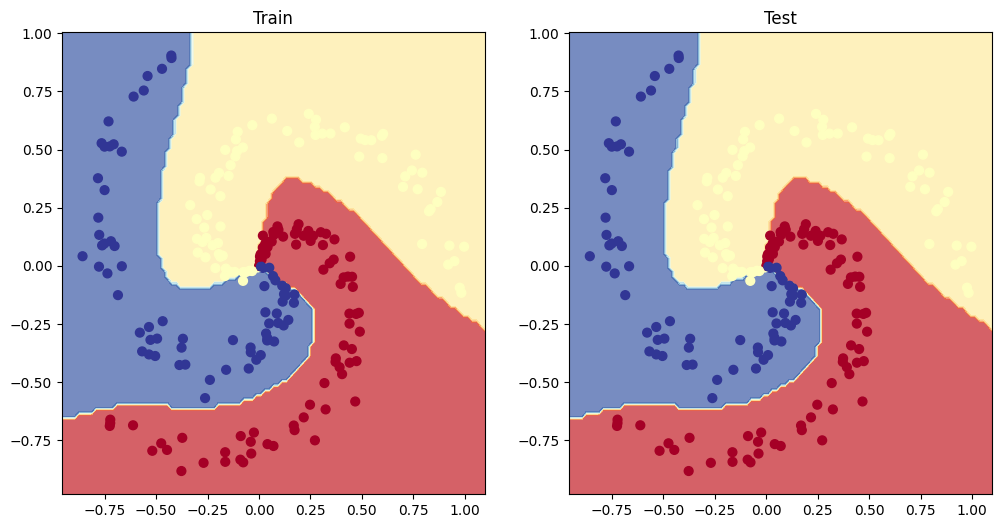

In [196]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_6, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model_6, X_train, y_train)